# Naive Bayes — Churn Prediction Model

Training a Gaussian Naive Bayes classifier on the churn dataset.
NB is extremely fast and works well when features are roughly
independent — good probabilistic baseline.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
from imblearn.over_sampling import SMOTE, SMOTENC

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [11]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "model_ready_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Make sure you run the notebook from the repo root or run the data prep pipeline first."
    )

df = pd.read_csv(data_path)
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
cols_before = set(df.columns)
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
actually_dropped = cols_before - set(df.columns)
print(f"Dropped {len(actually_dropped)} leaky/non-predictive features: {sorted(actually_dropped)}")

# --- SPLIT FIRST, THEN ENCODE (fit on train only) -------------------------
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train.loc[:, cat_cols] = ord_enc.fit_transform(X_train[cat_cols]).astype(int)
    X_test.loc[:, cat_cols] = ord_enc.transform(X_test[cat_cols]).astype(int)

# Validate & ensure all columns are numeric
for col in X_train.columns:
    coerced = pd.to_numeric(X_train[col], errors="coerce")
    n_failed = coerced.isna().sum() - X_train[col].isna().sum()
    if n_failed > 0:
        pct = n_failed / len(X_train) * 100
        print(f"  WARNING: '{col}' had {n_failed} ({pct:.1f}%) non-numeric values")

train_medians = X_train.apply(pd.to_numeric, errors="coerce").median()
X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(train_medians)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(train_medians)

# Compute categorical column indices for SMOTENC
cat_col_indices = [X_train.columns.get_loc(c) for c in cat_cols] if cat_cols else []

def make_sampler():
    return SMOTENC(categorical_features=cat_col_indices, random_state=42) if cat_col_indices else SMOTE(random_state=42)


print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 9 leaky/non-predictive features: ['Days_To_Close_Post_Renewal', 'Payment_Method', 'Payment_Timeframe', 'Renewal_Year', 'Total_Net_Paid', 'Total_Renewal_Score_New', 'net_paid_vs_last', 'price_change_abs', 'price_change_pct']

Features: 51
Train: 91115, Test: 22779
Churn rate: 11.12%


## 2 · Baseline Naive Bayes

Using a Pipeline with StandardScaler + GaussianNB so that
the scaler is fit only on training data (no leakage).

In [12]:
nb_pipe_base = Pipeline([
    ("smote", make_sampler()),
    ("scaler", StandardScaler()),
    ("nb", GaussianNB()),
])
nb_pipe_base.fit(X_train, y_train)

y_pred_base = nb_pipe_base.predict(X_test)
y_prob_base = nb_pipe_base.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC AUC": roc_auc_score(y_test, y_prob_base),
}

print("=" * 60)
print("BASELINE NAIVE BAYES RESULTS")
print("=" * 60)
for k, v in baseline_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE NAIVE BAYES RESULTS
Accuracy  : 0.8743
Precision : 0.4595
Recall    : 0.7356
F1 Score  : 0.5656
ROC AUC   : 0.9028

              precision    recall  f1-score   support

         Won       0.96      0.89      0.93     20245
     Churned       0.46      0.74      0.57      2534

    accuracy                           0.87     22779
   macro avg       0.71      0.81      0.75     22779
weighted avg       0.91      0.87      0.89     22779



## 3 · Hyperparameter Tuning

GaussianNB has one tunable param: `var_smoothing`.
We wrap scaler + model in a Pipeline so each CV fold
fits its own scaler — no data leakage.

In [13]:
smoothing_values = [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_smooth = None

results = []
for vs in smoothing_values:
    pipe = Pipeline([
        ("smote", make_sampler()),
        ("scaler", StandardScaler()),
        ("nb", GaussianNB(var_smoothing=vs)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_strat, scoring="f1")
    mean_f1 = scores.mean()
    results.append((vs, mean_f1, scores.std()))
    print(f"var_smoothing={vs:.0e}: F1={mean_f1:.4f} (+/- {scores.std():.4f})")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_smooth = vs

print(f"\nBest var_smoothing: {best_smooth:.0e}  ->  F1={best_f1:.4f}")

var_smoothing=1e-12: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-10: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-09: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-08: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-07: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-06: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-05: F1=0.5709 (+/- 0.0018)
var_smoothing=1e-04: F1=0.5710 (+/- 0.0019)
var_smoothing=1e-03: F1=0.5708 (+/- 0.0018)
var_smoothing=1e-02: F1=0.5697 (+/- 0.0018)

Best var_smoothing: 1e-04  ->  F1=0.5710


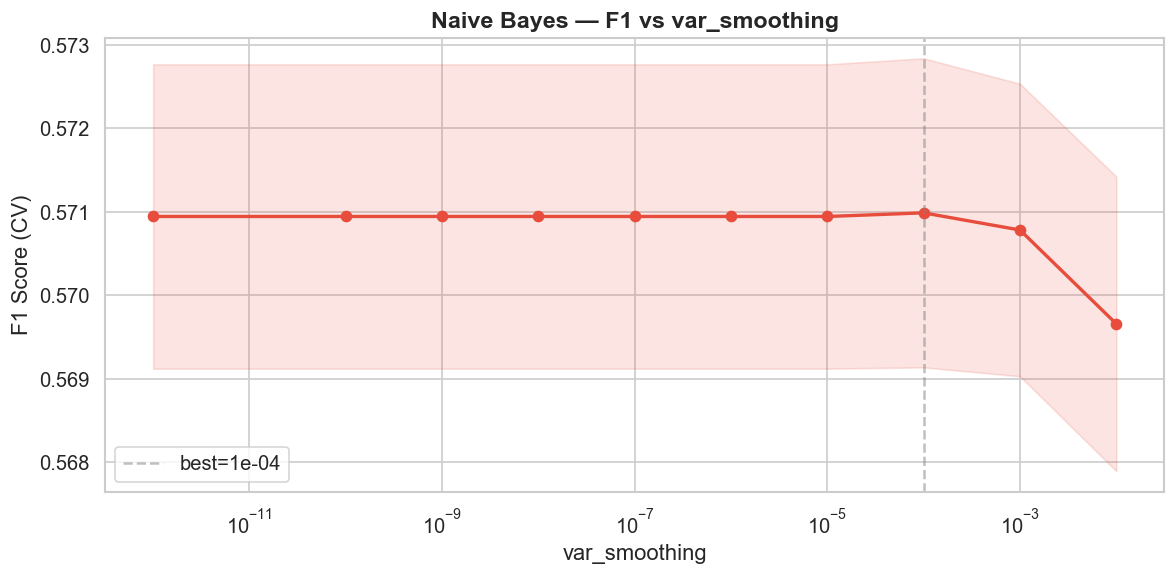

In [14]:
res_df = pd.DataFrame(results, columns=["var_smoothing", "f1_mean", "f1_std"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(res_df["var_smoothing"], res_df["f1_mean"], "o-", color="#e74c3c", linewidth=2)
ax.fill_between(res_df["var_smoothing"],
                res_df["f1_mean"] - res_df["f1_std"],
                res_df["f1_mean"] + res_df["f1_std"],
                alpha=0.15, color="#e74c3c")
ax.set_xlabel("var_smoothing")
ax.set_ylabel("F1 Score (CV)")
ax.set_title("Naive Bayes — F1 vs var_smoothing", fontsize=14, fontweight="bold")
ax.axvline(x=best_smooth, color="gray", linestyle="--", alpha=0.5, label=f"best={best_smooth:.0e}")
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Best Model Evaluation

In [15]:
# guard: fallback if tuning cell wasn't run
if best_smooth is None:
    warnings.warn("best_smooth not found — using default 1e-9.")
    best_smooth = 1e-9

best_nb_pipe = Pipeline([
    ("smote", make_sampler()),
    ("scaler", StandardScaler()),
    ("nb", GaussianNB(var_smoothing=best_smooth)),
])
best_nb_pipe.fit(X_train, y_train)

y_pred = best_nb_pipe.predict(X_test)
y_prob = best_nb_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob),
}

print("=" * 60)
print("TUNED NAIVE BAYES RESULTS")
print("=" * 60)
for k, v in tuned_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED NAIVE BAYES RESULTS
Accuracy  : 0.8742
Precision : 0.4592
Recall    : 0.7356
F1 Score  : 0.5654
ROC AUC   : 0.9028

              precision    recall  f1-score   support

         Won       0.96      0.89      0.93     20245
     Churned       0.46      0.74      0.57      2534

    accuracy                           0.87     22779
   macro avg       0.71      0.81      0.75     22779
weighted avg       0.91      0.87      0.89     22779



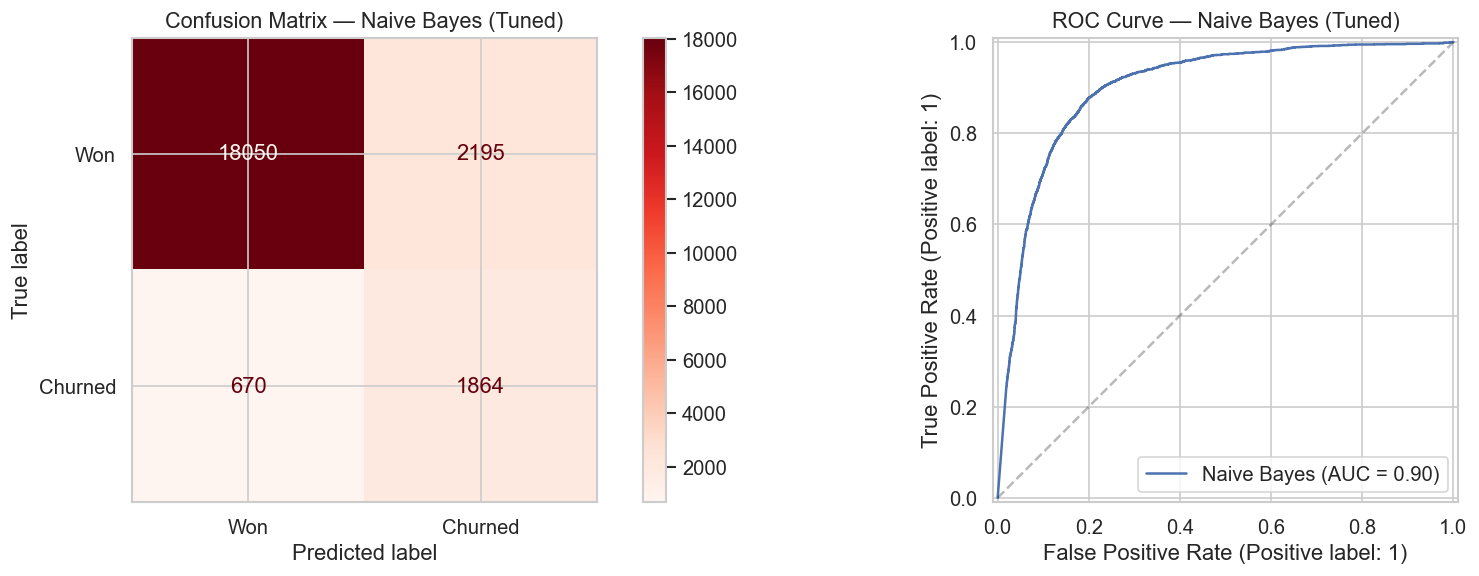

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Reds"
)
axes[0].set_title("Confusion Matrix — Naive Bayes (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="Naive Bayes")
axes[1].set_title("ROC Curve — Naive Bayes (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Class Priors & Per-Feature Analysis

Learned class priors:
  Won:     0.5000
  Churned: 0.5000



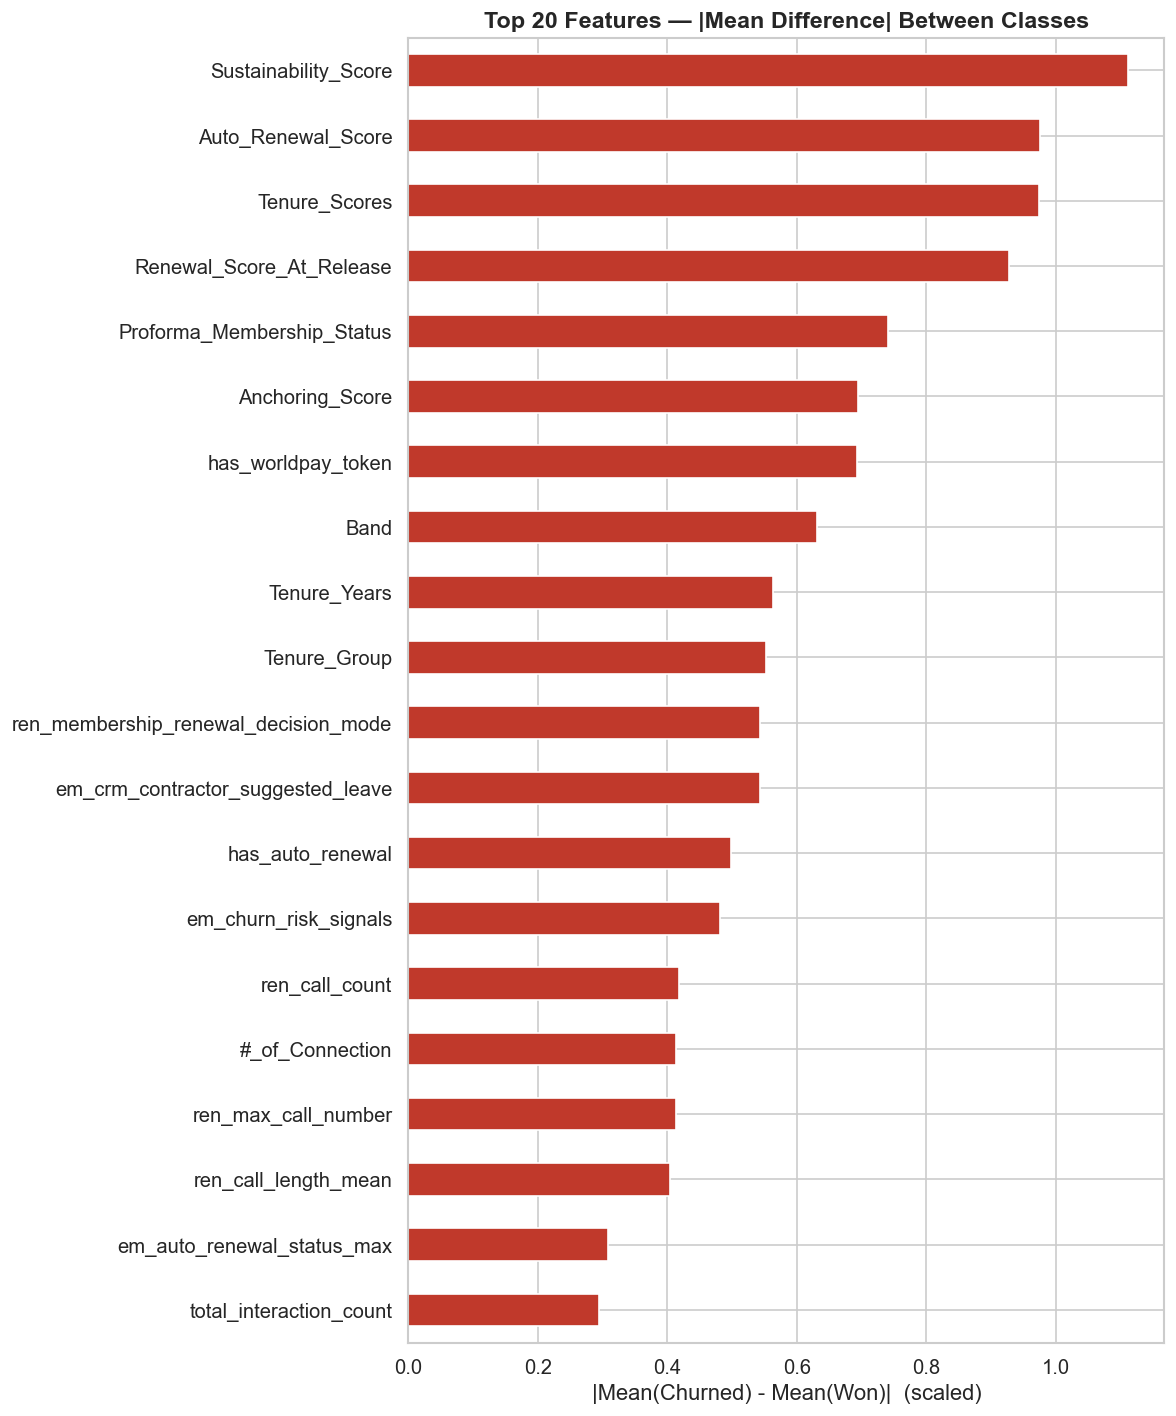

In [17]:
# extract the NB model from the pipeline
best_nb = best_nb_pipe.named_steps["nb"]

print("Learned class priors:")
print(f"  Won:     {best_nb.class_prior_[0]:.4f}")
print(f"  Churned: {best_nb.class_prior_[1]:.4f}")
print()

# which features have the biggest difference in means between classes?
mean_diff = np.abs(best_nb.theta_[1] - best_nb.theta_[0])
feat_diff = pd.Series(mean_diff, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
feat_diff.tail(20).plot.barh(ax=ax, color="#c0392b", edgecolor="white")
ax.set_title("Top 20 Features — |Mean Difference| Between Classes", fontsize=14, fontweight="bold")
ax.set_xlabel("|Mean(Churned) - Mean(Won)|  (scaled)")
plt.tight_layout()
plt.show()

## Summary

In [18]:
summary = pd.DataFrame({"Baseline": baseline_metrics, "Tuned": tuned_metrics})
summary = summary.round(4)
try:
    print(summary.to_markdown())
except ImportError:
    print(summary.to_string())

|           |   Baseline |   Tuned |
|:----------|-----------:|--------:|
| Accuracy  |     0.8743 |  0.8742 |
| Precision |     0.4595 |  0.4592 |
| Recall    |     0.7356 |  0.7356 |
| F1 Score  |     0.5656 |  0.5654 |
| ROC AUC   |     0.9028 |  0.9028 |
